In [1]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sb
from sklearn.decomposition import PCA
import os

# EDA on IP

## Loading Dataset

In [2]:
mat_ip=sio.loadmat(r'D:\Study\BSC\7th Semester\CSE 4100 - Project or Thesis whith Seminar Part I\Hyperspectral Imgae processing\HSI-Thesis\data\Indian_pines.mat')
print(mat_ip.keys())

dict_keys(['__header__', '__version__', '__globals__', 'indian_pines_corrected'])


In [3]:
hsi_ip=mat_ip['indian_pines_corrected']

## Shape of the dataset

In [4]:
hsi_ip.shape # height= 145, width=145, bands=200

(145, 145, 200)

## Basic information

In [5]:
print("Datatype:", hsi_ip.dtype)

print("Minimum:", np.min(hsi_ip))
print("Maximum:", np.max(hsi_ip))

print("Mean:", np.mean(hsi_ip))
print("Std:", np.std(hsi_ip))

Datatype: uint16
Minimum: 955
Maximum: 9604
Mean: 2652.3891098692034
Std: 1592.3401203795756


## showing as RGB

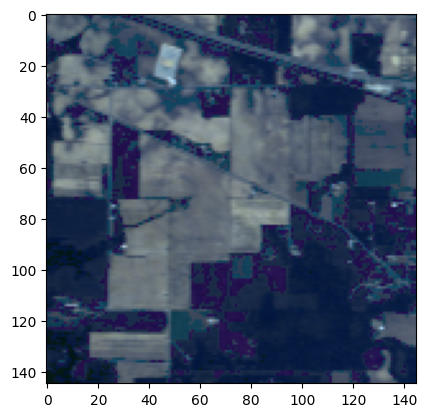

In [6]:
rgb_ip=hsi_ip[:,:,[30,20,10]]
rgb_ip=(rgb_ip-rgb_ip.min())/(rgb_ip.max()-rgb_ip.min())

plt.imshow(rgb_ip)
plt.show()

## Visualizing Individual Bands

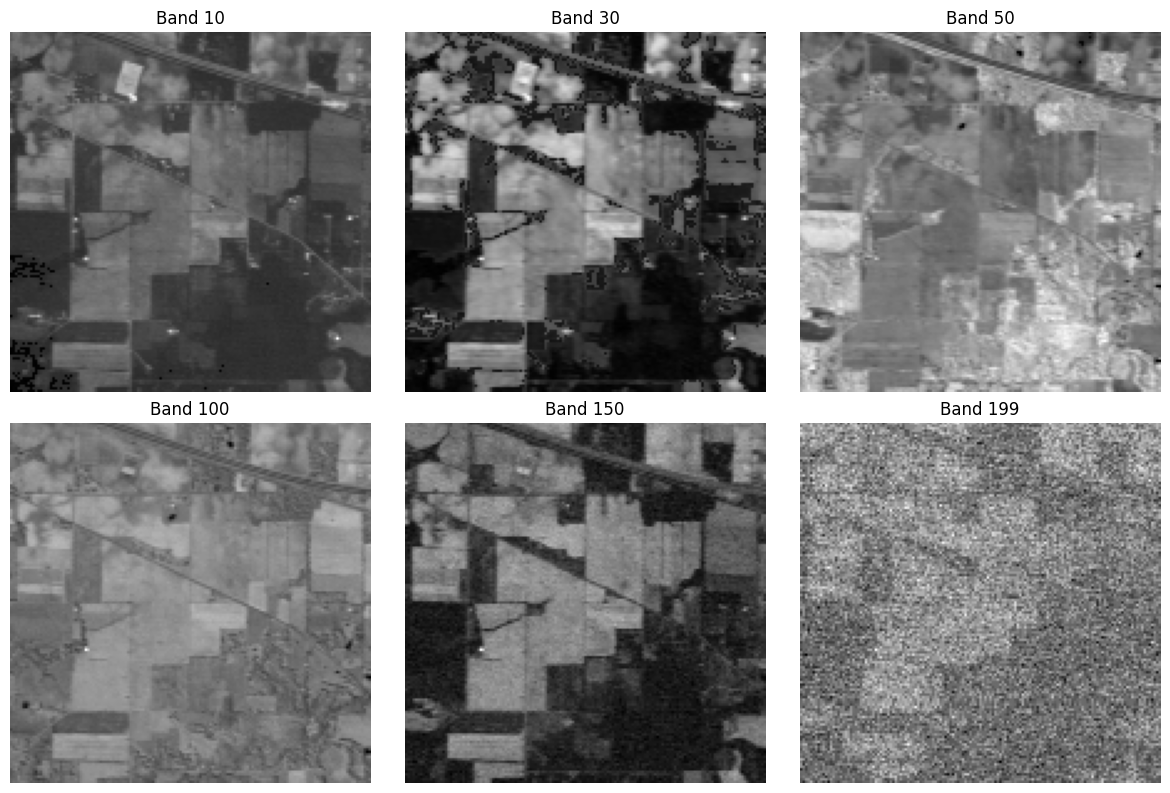

In [7]:
bands = [10,30,50,100,150,199]

plt.figure(figsize=(12,8))

for i,b in enumerate(bands):
    plt.subplot(2,3,i+1)
    plt.imshow(hsi_ip[:,:,b], cmap='gray')
    plt.title(f'Band {b}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Histogram of Pixel Values

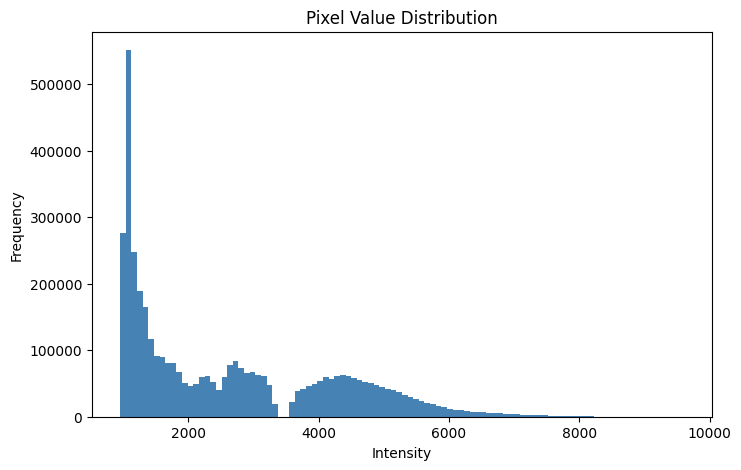

In [8]:
plt.figure(figsize=(8,5))

plt.hist(hsi_ip.flatten(),
         bins=100,
         color='steelblue')

plt.title("Pixel Value Distribution")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

## Mean Intensity of Each Band

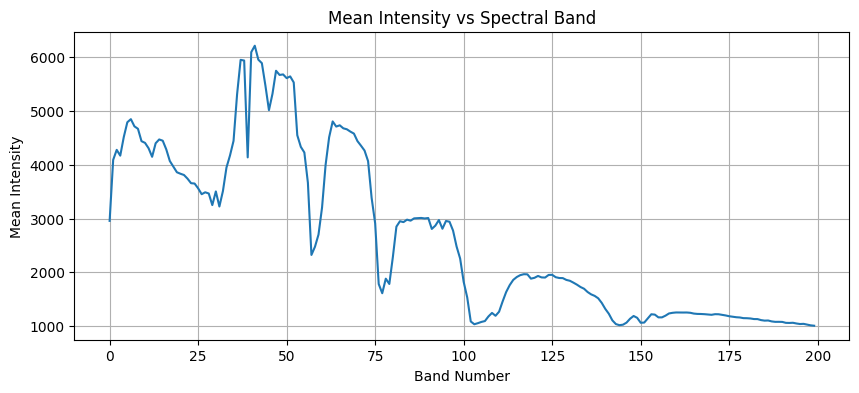

In [9]:
band_mean = np.mean(hsi_ip, axis=(0,1))

plt.figure(figsize=(10,4))
plt.plot(band_mean)
plt.xlabel("Band Number")
plt.ylabel("Mean Intensity")
plt.title("Mean Intensity vs Spectral Band")
plt.grid()
plt.show()

## Standard Deviation of Each Band

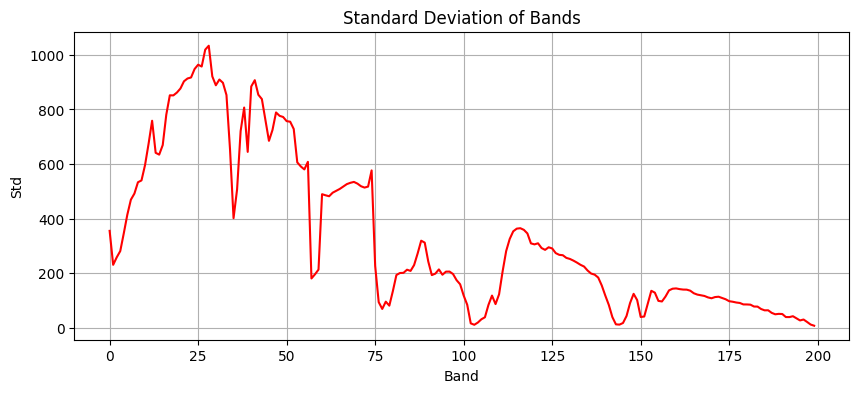

In [10]:
band_std = np.std(hsi_ip, axis=(0,1))

plt.figure(figsize=(10,4))
plt.plot(band_std,color='red')
plt.grid()
plt.title("Standard Deviation of Bands")
plt.xlabel("Band")
plt.ylabel("Std")
plt.show()

## Spectral Signature

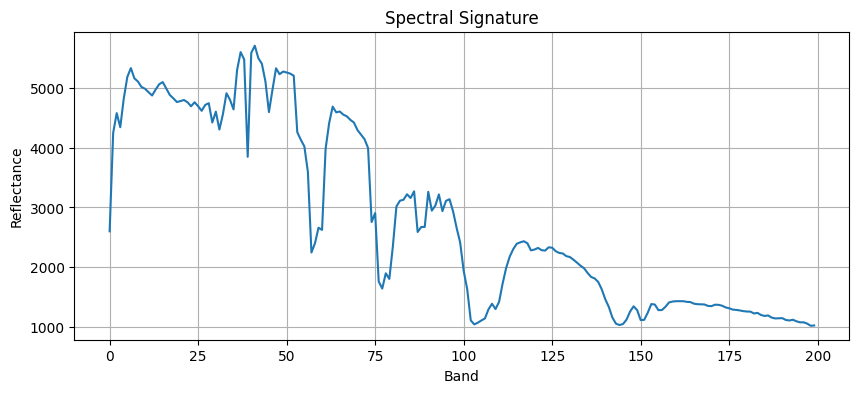

In [11]:
x=70
y=70

signature = hsi_ip[x,y,:]

plt.figure(figsize=(10,4))
plt.plot(signature)
plt.title("Spectral Signature")
plt.xlabel("Band")
plt.ylabel("Reflectance")
plt.grid()
plt.show()

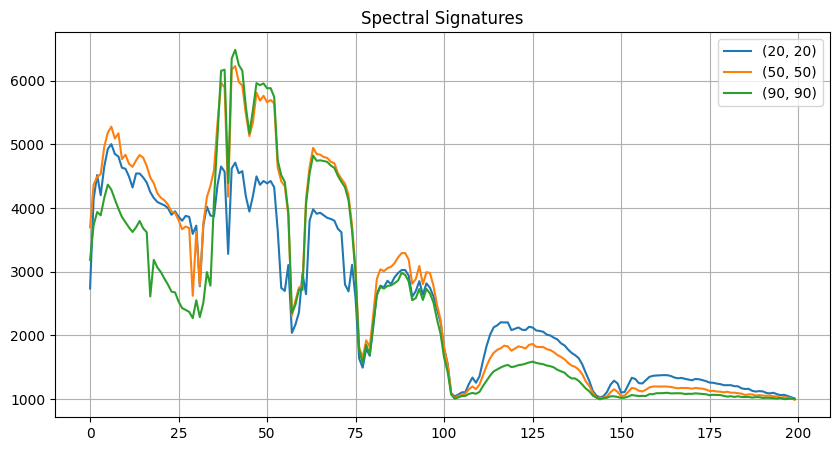

In [12]:
pixels=[(20,20),(50,50),(90,90)]

plt.figure(figsize=(10,5))

for p in pixels:
    plt.plot(hsi_ip[p[0],p[1],:],label=str(p))

plt.legend()
plt.grid()
plt.title("Spectral Signatures")
plt.show()

## Correlation Between Bands

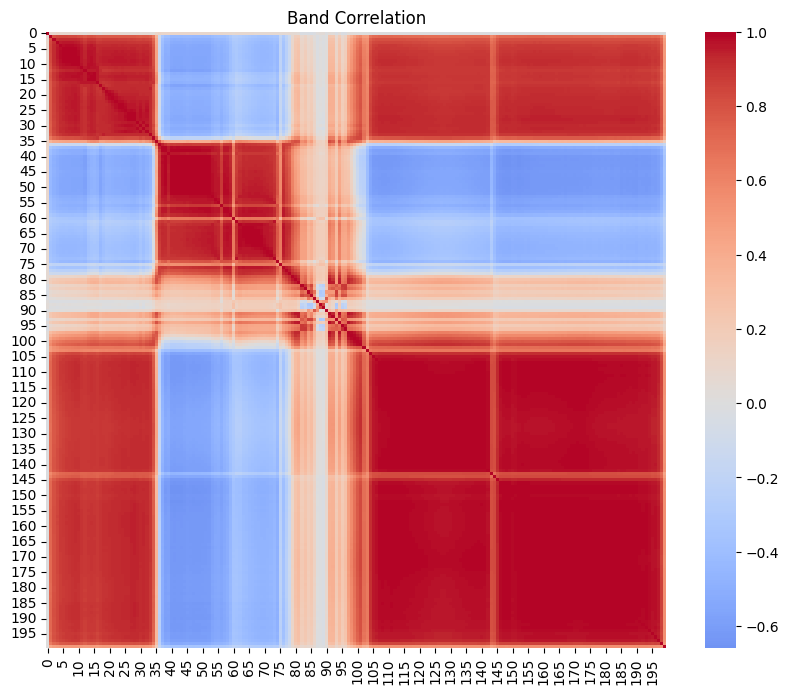

In [13]:
X = hsi_ip.reshape(-1,hsi_ip.shape[2])

corr = np.corrcoef(X.T)

plt.figure(figsize=(10,8))
sb.heatmap(corr, cmap='coolwarm',center=0)

plt.title("Band Correlation")
plt.show()

## PCA

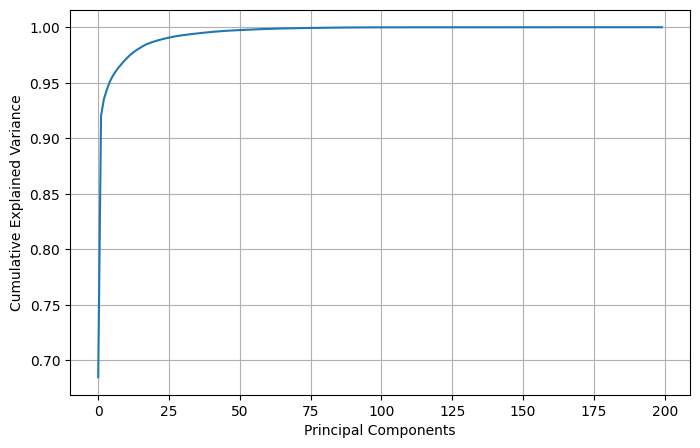

In [14]:
X = hsi_ip.reshape(-1,hsi_ip.shape[2])

pca = PCA()

pca.fit(X)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()

## PCA Image

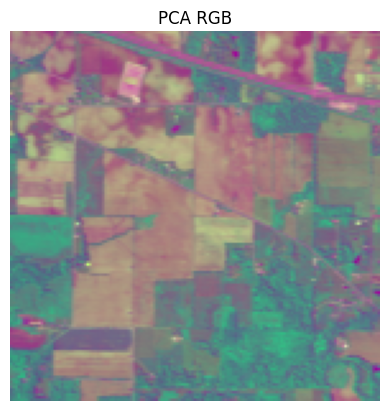

In [15]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X)

img = X_pca.reshape(hsi_ip.shape[0],hsi_ip.shape[1],3)

img = (img-img.min())/(img.max()-img.min())

plt.imshow(img)
plt.title("PCA RGB")
plt.axis("off")
plt.show()

## Noise Detection

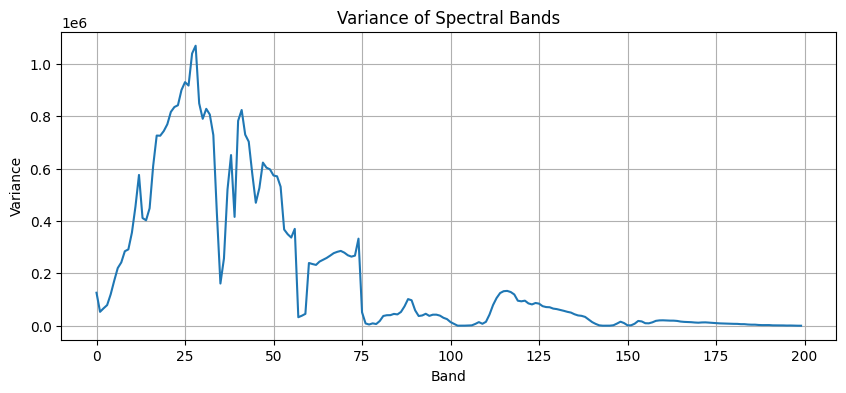

In [16]:
variance = np.var(hsi_ip,axis=(0,1))

plt.figure(figsize=(10,4))
plt.plot(variance)
plt.grid()
plt.title("Variance of Spectral Bands")
plt.xlabel("Band")
plt.ylabel("Variance")
plt.show()

## Missing Values

In [17]:
print("NaN values :", np.isnan(hsi_ip).sum())
print("Infinite values :", np.isinf(hsi_ip).sum())

NaN values : 0
Infinite values : 0


## Boxplot of Band Intensities

C:\Users\Aikya\AppData\Local\Temp\ipykernel_6900\1424539419.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sample_bands)


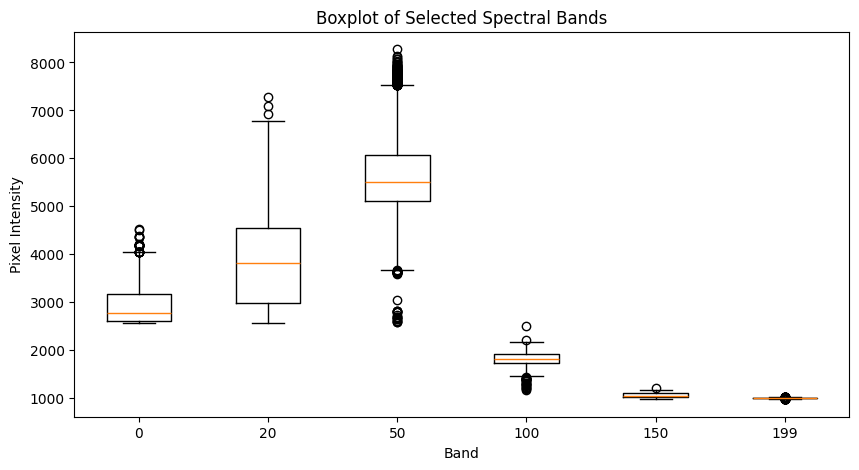

In [18]:
sample_bands = [0, 20, 50, 100, 150, 199]
data = [hsi_ip[:, :, b].flatten() for b in sample_bands]

plt.figure(figsize=(10,5))
plt.boxplot(data, labels=sample_bands)
plt.title("Boxplot of Selected Spectral Bands")
plt.xlabel("Band")
plt.ylabel("Pixel Intensity")
plt.show()

# EDA on IP ground Truth

## Loading GT

In [19]:
mat_ip_gt = sio.loadmat(r'D:\Study\BSC\7th Semester\CSE 4100 - Project or Thesis whith Seminar Part I\Hyperspectral Imgae processing\HSI-Thesis\data\Indian_pines_gt.mat')
print(mat_ip_gt.keys())

dict_keys(['__header__', '__version__', '__globals__', 'indian_pines_gt'])


In [20]:
hsi_ip_gt = mat_ip_gt['indian_pines_gt']      # Replace with your variable name

print(hsi_ip_gt.shape)
print(hsi_ip_gt.dtype)

(145, 145)
uint8


## Visualize Ground Truth

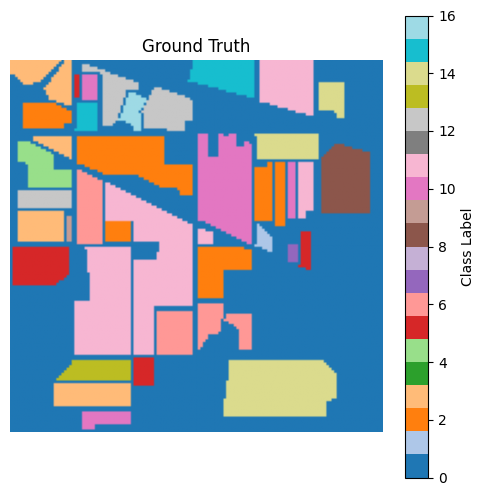

In [21]:
plt.figure(figsize=(6,6))
plt.imshow(hsi_ip_gt, cmap='tab20')
plt.colorbar(label='Class Label')
plt.title("Ground Truth")
plt.axis("off")
plt.show()

## Basic Information

In [22]:
print("Shape:", hsi_ip_gt.shape)
print("Minimum Label:", np.min(hsi_ip_gt))
print("Maximum Label:", np.max(hsi_ip_gt))

classes = np.unique(hsi_ip_gt)

print("Unique Classes:", classes)
print("Number of Classes:", len(classes)-1)   # Excluding background (0)

Shape: (145, 145)
Minimum Label: 0
Maximum Label: 16
Unique Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Number of Classes: 16


## Class Distribution

In [23]:
labels, counts = np.unique(hsi_ip_gt, return_counts=True)

for l, c in zip(labels, counts):
    print(f"Class {l}: {c} pixels")

Class 0: 10776 pixels
Class 1: 46 pixels
Class 2: 1428 pixels
Class 3: 830 pixels
Class 4: 237 pixels
Class 5: 483 pixels
Class 6: 730 pixels
Class 7: 28 pixels
Class 8: 478 pixels
Class 9: 20 pixels
Class 10: 972 pixels
Class 11: 2455 pixels
Class 12: 593 pixels
Class 13: 205 pixels
Class 14: 1265 pixels
Class 15: 386 pixels
Class 16: 93 pixels


## Bar Chart of Class Distribution

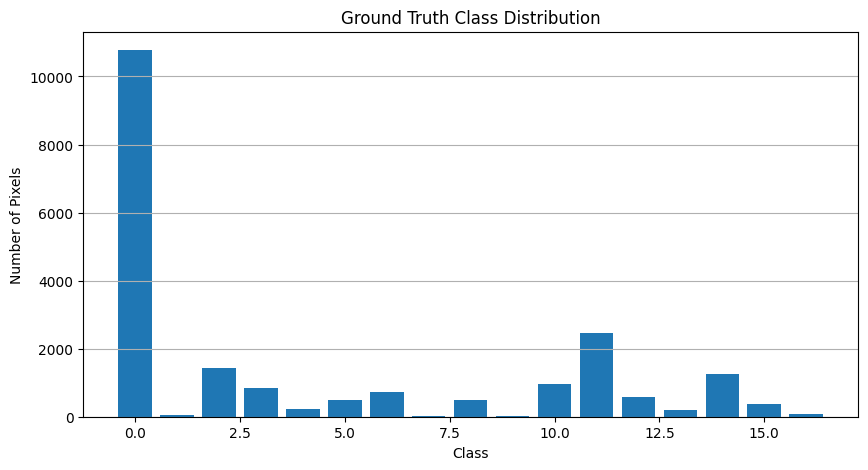

In [24]:
plt.figure(figsize=(10,5))

plt.bar(labels, counts)

plt.xlabel("Class")
plt.ylabel("Number of Pixels")
plt.title("Ground Truth Class Distribution")
plt.grid(axis='y')
plt.show()

## Pie Chart

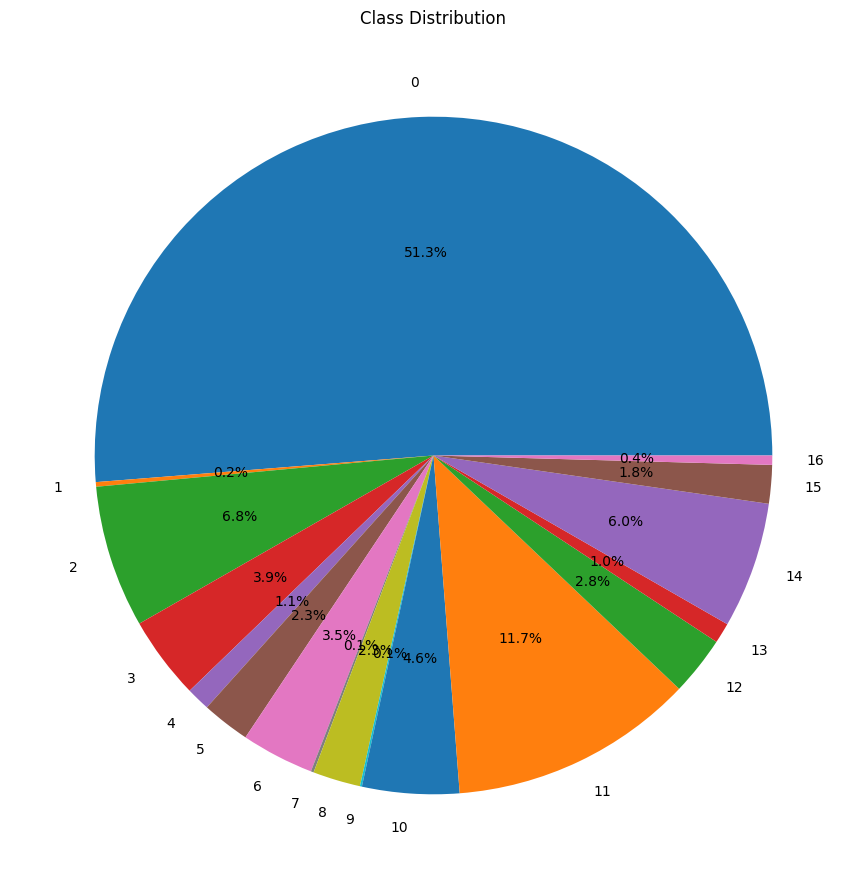

In [25]:
plt.figure(figsize=(11,11))

plt.pie(counts,labels=labels,autopct='%1.1f%%')

plt.title("Class Distribution")
plt.show()

## Background vs Labeled Pixels

In [26]:
background = np.sum(hsi_ip_gt == 0)
labeled = np.sum(hsi_ip_gt > 0)

print("Background Pixels:", background)
print("Labeled Pixels:", labeled)

Background Pixels: 10776
Labeled Pixels: 10249


## Heatmap of Labels

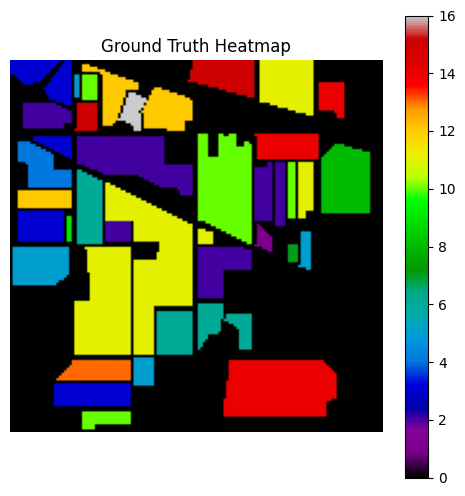

In [27]:
plt.figure(figsize=(6,6))

plt.imshow(hsi_ip_gt, cmap='nipy_spectral')

plt.title("Ground Truth Heatmap")
plt.colorbar()
plt.axis("off")
plt.show()

## Class Imbalance

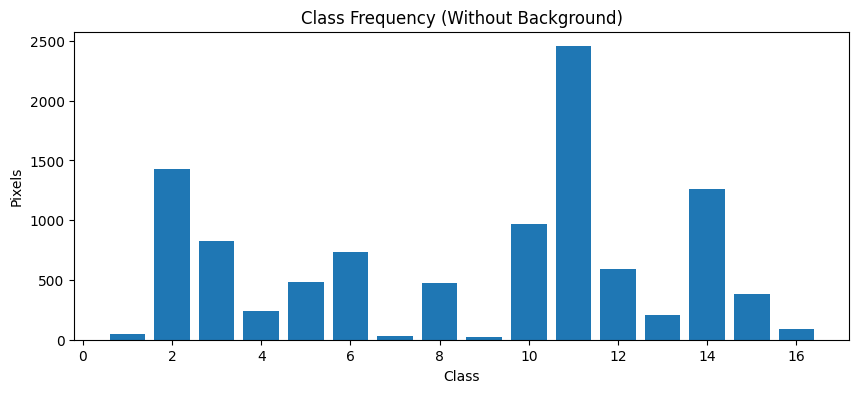

In [28]:
counts_no_bg = counts[labels != 0]
labels_no_bg = labels[labels != 0]

plt.figure(figsize=(10,4))

plt.bar(labels_no_bg, counts_no_bg)

plt.xlabel("Class")
plt.ylabel("Pixels")
plt.title("Class Frequency (Without Background)")
plt.show()

## Percentage of Each Class

In [29]:
labels, counts = np.unique(hsi_ip_gt, return_counts=True)

total = np.sum(counts)

for l, c in zip(labels, counts):
    print(f"Class {l}: {100*c/total:.2f}%")

Class 0: 51.25%
Class 1: 0.22%
Class 2: 6.79%
Class 3: 3.95%
Class 4: 1.13%
Class 5: 2.30%
Class 6: 3.47%
Class 7: 0.13%
Class 8: 2.27%
Class 9: 0.10%
Class 10: 4.62%
Class 11: 11.68%
Class 12: 2.82%
Class 13: 0.98%
Class 14: 6.02%
Class 15: 1.84%
Class 16: 0.44%


# Overlay Ground Truth on IP False RGB

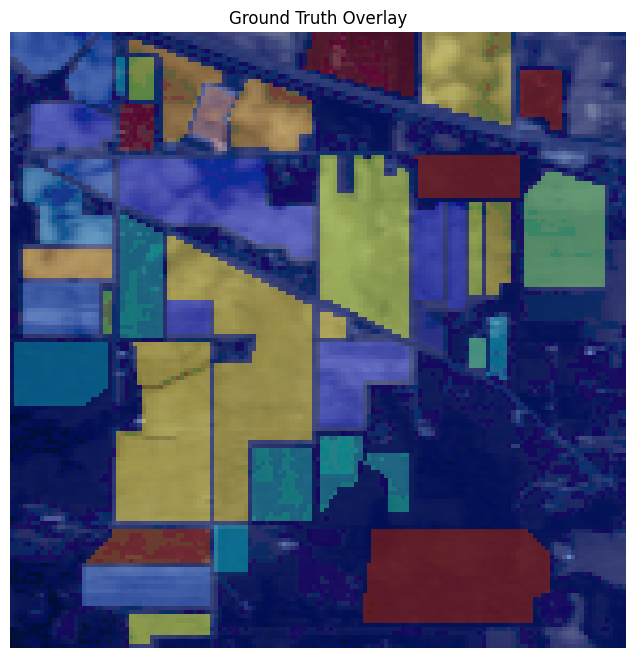

In [30]:
rgb = hsi_ip[:, :, [30, 20, 10]]
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.figure(figsize=(8,8))
plt.imshow(rgb)
plt.imshow(hsi_ip_gt, cmap='jet', alpha=0.35)
plt.title("Ground Truth Overlay")
plt.axis("off")
plt.show()